# Examples of Plot Visualisations from VFP Output (RefNX)

We'll use a couple of example `vfp` objects saved from a prior model (the bilayer constraint example). In this case it doesn't matter what the model is, this showcases some examples of how to plot `reflectivity profiles`, `SLD profiles` and `vfp profiles`.

NOTE::: Probably want to change the example used so don't have to have the SLDConstraint Class redefined!

In [5]:
import pickle
import matplotlib.pyplot as plt
import pathlib
import numpy as np
import os

from refnx.analysis import GlobalObjective, Parameter, Objective, CurveFitter
from refnx.reflect import ReflectModel, SLD
from refnx.dataset import ReflectDataset

import vfp


In [8]:
class SLDConstraint:
    """
    Class with two methods that are used by the VFP.
    `layer_choices` returns the indices of the layers that we'll constrain together.
    '__call__' Uses the  a function that   
    """
    def __init__(self, required_pars: dict[float]):
        self.required_pars = required_pars
        
    def layer_choices(self) -> list[int]:
        return [2, 3, 4, 5]
        
    def __call__(self, layer_integrals: list[float]) -> tuple[list[int], list[float]]:
        lay2_int, lay3_int, lay4_int, lay5_int = layer_integrals
        
        surf_inner_head_vf, surf_inner_head_sld, surf_inner_tail_sld, b_surf_inner_head, b_surf_inner_tail, surf_outer_head_vf, surf_outer_head_sld, surf_outer_tail_sld, b_surf_outer_head, b_surf_outer_tail, water_sld = map(
            self.required_pars.get,
            ['surf_inner_head_vf', 
             'surf_inner_head_sld',
             'surf_inner_tail_sld',
             'b_surf_inner_head',
             'b_surf_inner_tail',
             'surf_outer_head_vf',
             'surf_outer_head_sld',
             'surf_outer_tail_sld',
             'b_surf_outer_head',
             'b_surf_outer_tail', 
             'water_sld'
             ]
        )
        
        # using the integrals, constrain the volume fraction of the tail
        surf_tail_vf_inner = (surf_inner_head_vf
                    * ((surf_inner_head_sld * b_surf_inner_tail) / (b_surf_inner_head * surf_inner_tail_sld)) 
                    * (lay2_int / lay3_int)
        )
        
        surf_tail_vf_outer = (surf_outer_head_vf
                    * ((surf_outer_head_sld * b_surf_outer_tail) / (b_surf_outer_head * surf_outer_tail_sld)) 
                    * (lay5_int / lay4_int)
        )
        
        inner_water_vf = 1 - (surf_tail_vf_inner)
        outer_water_vf = 1 - (surf_tail_vf_outer)
        
        # now we have outer_water_vf, we can calculate the true sld of the outer layer:
        layer_idx = [3, 4] # outer layer sld index
        altered_sld = [
            (inner_water_vf*water_sld + surf_tail_vf_inner*surf_inner_tail_sld),
            (outer_water_vf*water_sld + surf_tail_vf_outer*surf_outer_tail_sld)
        ]
        
        return layer_idx, altered_sld

### Load the pre-saved `vfp`:

In [11]:
dataset_dir = pathlib.Path(vfp.__path__[0]).parents[1] / 'docs'

with open(dataset_dir / "d2o_vfp_example.pkl", "rb") as f:
    d2o_vfp = pickle.load(f)
with open(dataset_dir / "h2o_vfp_example.pkl", "rb") as f:
    h2o_vfp = pickle.load(f)
with open(dataset_dir / "d2o_dtails_vfp_example.pkl", "rb") as f:
    d2o_dtails_vfp = pickle.load(f)

### Built-in Plotting Options For Each `vfp` 

Plot just the SLD profile:

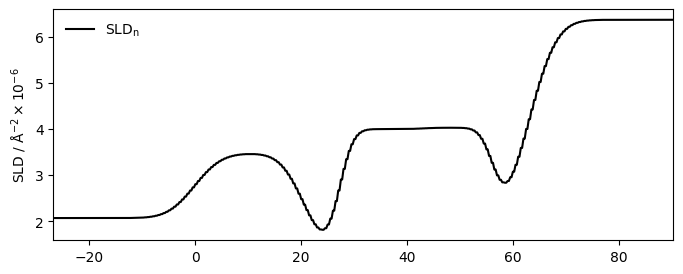

In [12]:
fig, ax = d2o_vfp.plot(plots_required=["sld"])
plt.show()

Plot just the volume fraction profile:

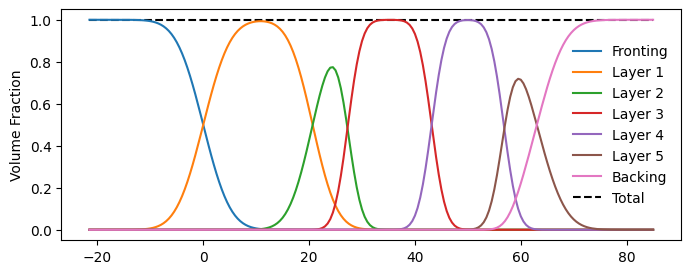

In [13]:
fig, ax = d2o_vfp.plot(plots_required=["vfp"])
plt.show()

Plot just the surface visualisation:

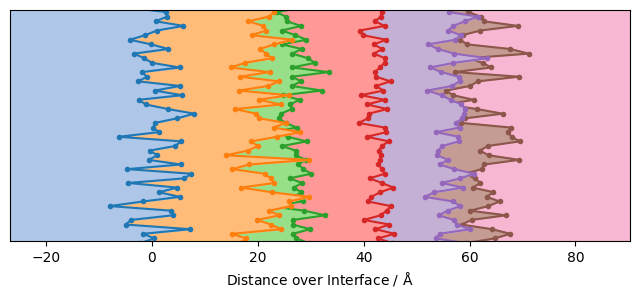

In [14]:
fig, ax = d2o_vfp.plot(plots_required=["surfaces"])
plt.show()

Or any combination can be requested within the `plots_required`. If this isn't specified it defaults to showing all 3.

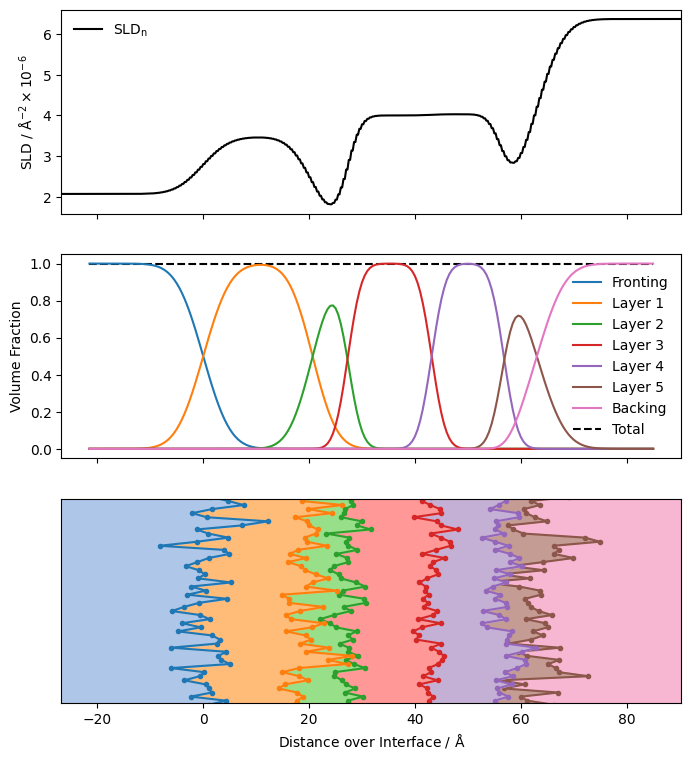

In [15]:
fig, ax = d2o_vfp.plot()
plt.show()

### Labeling the Materials

We can label the different components....

### Choosing a surface to align with

We can decide which interface counts as `z=0`. This is particularly useful if there are different model structures.

### Other options

Think there is the total_sld and others kwargs to add here still...
Add something on posterior samples etc too?

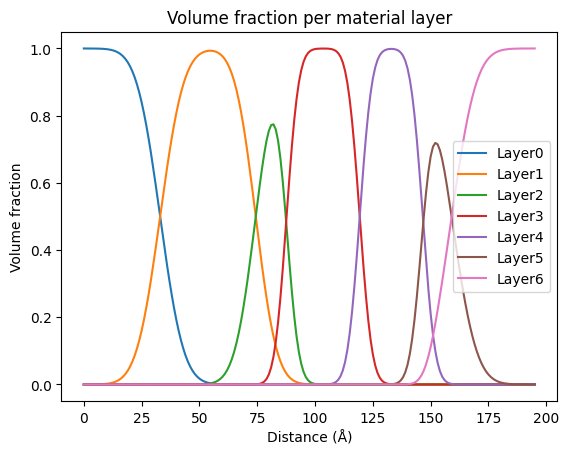

In [20]:
## Manual access of VFP that can enable custom plotting
for material in range(len(d2o_vfp.vfs_for_display()[0])):
    plt.plot(d2o_vfp.vfs_for_display()[0][material], label="Layer" + str(material))
plt.title("Volume fraction per material layer")
plt.xlabel("Distance (Å)")
plt.ylabel("Volume fraction")
plt.legend()
plt.show()

### Overlay Multiple `vfp`

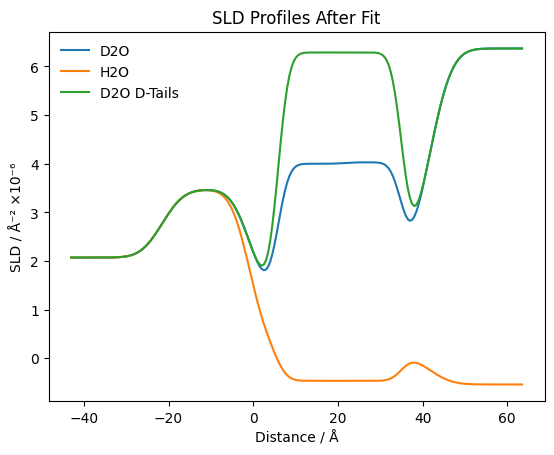

In [21]:
fig, ax = plt.subplots()
for vfp_obj, label in [(d2o_vfp, "D2O"), (h2o_vfp, "H2O"), (d2o_dtails_vfp, "D2O D-Tails")]:
    z, all_slds = vfp_obj.z_and_sld()
    ax.plot(z + vfp_obj.sld_offset(), all_slds[:, 0], label=label)  # sld_n
ax.set_ylabel("SLD / Å⁻² ×10⁻⁶")
ax.set_xlabel("Distance / Å")
ax.legend(frameon=False)
plt.title("SLD Profiles After Fit")
plt.show()

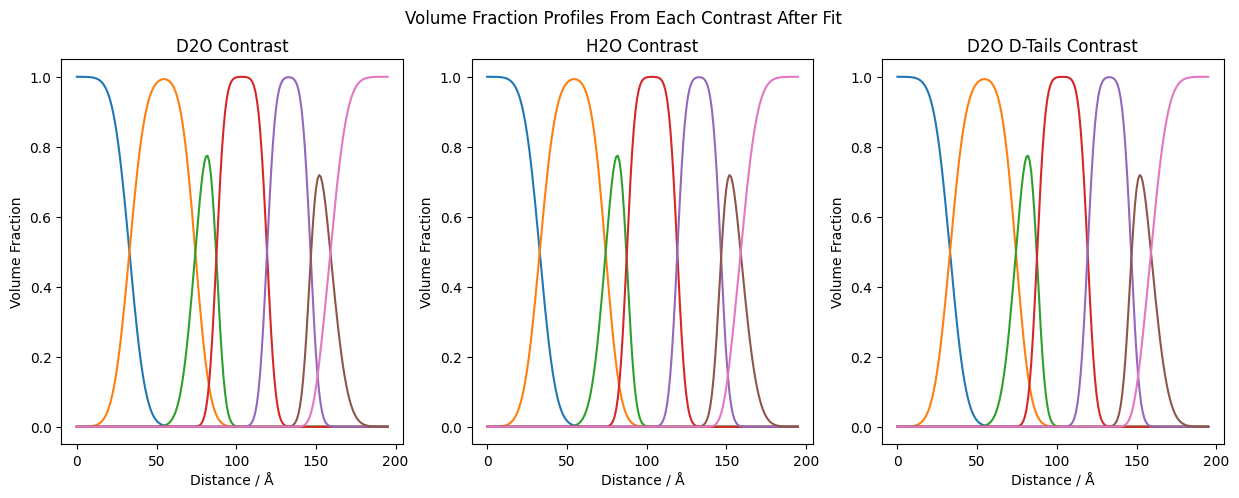

In [25]:
fig, ax = plt.subplots(1,3, figsize=(15,5))
fig.suptitle("Volume Fraction Profiles From Each Contrast After Fit")
for idx, (vfp_obj, lbl) in enumerate([(d2o_vfp, "D2O"), (h2o_vfp, "H2O"), (d2o_dtails_vfp, "D2O D-Tails")]):
    for material in range(len(vfp_obj.vfs_for_display()[0])):
        ax[idx].plot(vfp_obj.vfs_for_display()[0][material])
    ax[idx].set_title(f"{lbl} Contrast")
    ax[idx].set_xlabel("Distance / Å")
    ax[idx].set_ylabel("Volume Fraction")
plt.show()

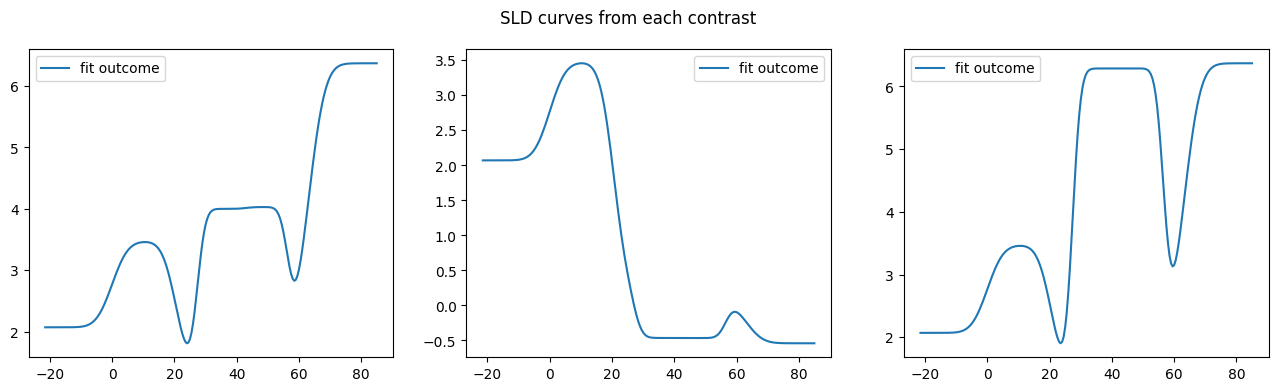

In [26]:
fig, ax = plt.subplots(1,3, figsize=(16,4))
fig.suptitle("SLD curves from each contrast")
ax[0].plot(d2o_vfp.z_and_sld()[0],d2o_vfp.z_and_sld()[1][:,0], label='fit outcome')
ax[0].legend()
ax[1].plot(h2o_vfp.z_and_sld()[0],h2o_vfp.z_and_sld()[1][:,0], label='fit outcome')
ax[1].legend()
ax[2].plot(d2o_dtails_vfp.z_and_sld()[0],d2o_dtails_vfp.z_and_sld()[1][:,0], label='fit outcome')
ax[2].legend()
plt.show()